# Demo: Text ↔ Image Animal Consistency Checker
(Multimodal verification: does the text describe the same animal as the image?)

**Components**:
- NER model (`ner_animal_final`) → extracts animal name from text
- Image classifier (fine-tuned ResNet18 on Animals-10) → predicts animal from photo

Goal: return `True` if text and image refer to the **same animal**

---

In [2]:
# ─── Imports ────────────────────────────────────────────────
import os
import torch
from IPython.display import Image, display
from transformers import pipeline

# Assume inference_image.py is in the same folder or in PYTHONPATH
from inference_image import predict_animal, load_model

# ─── Load models once ───────────────────────────────────────
print("Loading NER model...")
ner = pipeline(
    "ner",
    model="ner_animal_final",
    tokenizer="ner_animal_final",
    aggregation_strategy="simple",
    device=0 if torch.cuda.is_available() else -1
)

print("Loading image classification model...")
image_model = load_model("best_resnet18_animals10.pth")

print("Models ready.")

Device set to use cuda:0


Loading NER model...
Loading image classification model...
Models ready.


D:\Programs\Job\Data Science\Winstars\PythonProject\inference_image.py:24: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_loc

## Imports & Model Loading ##

In [3]:
# ─── Imports ────────────────────────────────────────────────
import os
from IPython.display import Image, display
from transformers import pipeline
from pipeline import predict_animal, load_model

# ─── Load models once ───────────────────────────────────────
print("Loading NER model...")
ner = pipeline(
    "ner",
    model="ner_animal_final",
    tokenizer="ner_animal_final",
    aggregation_strategy="simple",
    device=0 if torch.cuda.is_available() else -1
)

print("Loading image classification model...")
image_model = load_model("best_resnet18_animals10.pth")

print("Models ready.")

Device set to use cuda:0
Device set to use cuda:0


Loading NER model...
Loading image classification model...
Models ready.


## Check Function

In [4]:
def check(text: str, image_path: str) -> bool:
    """
    Check if the animal mentioned in the text matches the animal predicted from the image.
    Returns True if they match (after simple negation handling), False otherwise.
    """
    # 1. Extract animal from text
    entities = ner(text)
    extracted = None
    for entity in entities:
        if entity['entity_group'] == 'ANIMAL':
            extracted = entity['word'].lower().strip()
            break

    if not extracted:
        print(f"No animal found in text: {text}")
        return False

    # 2. Predict from image
    try:
        predicted = predict_animal(image_path, model=image_model).lower().strip()
    except Exception as e:
        print(f"Image error: {e}")
        return False

    # 3. Compare + negation handling
    print(f"Text     → {extracted}")
    print(f"Image    → {predicted}")

    is_match = extracted == predicted

    text_lower = text.lower()
    negation_words = ["not", "no", "isn't", "isnt", "doesn't", "dont", "never", "n't"]
    has_negation = any(w in text_lower for w in negation_words)

    if has_negation:
        print("→ Negation detected — inverting match")
        is_match = not is_match

    print(f"→ Final result: {is_match}")
    return is_match

Helper to show image + run check

In [5]:
def demo_check(text: str, image_path: str, title=""):
    """Run check() and display the image + result"""
    if not os.path.exists(image_path):
        print(f"Image not found: {image_path}")
        return

    print(f"\n{'═'*70}")
    print(f"Demo: {title}")
    print(f"Text: {text}")
    print(f"Image: {image_path}")

    display(Image(filename=image_path, width=400))

    result = check(text, image_path)
    print(f"\nFinal verdict: {result}")
    print("═"*70 + "\n")

## Normal positive examples ##


══════════════════════════════════════════════════════════════════════
Demo: Cat – positive match
Text: There is a beautiful cat in the picture.
Image: images/cat.jpg


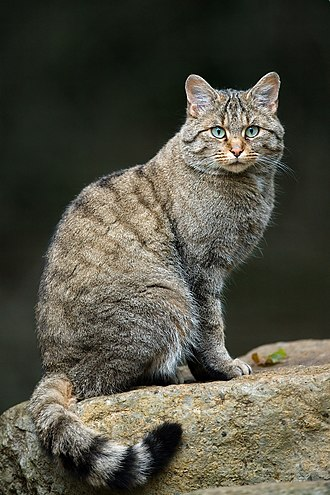

Text     → cat
Image    → cat
→ Final result: True

Final verdict: True
══════════════════════════════════════════════════════════════════════


══════════════════════════════════════════════════════════════════════
Demo: Cow – positive
Text: This picture shows a dog here
Image: images/dog-hero.jpg


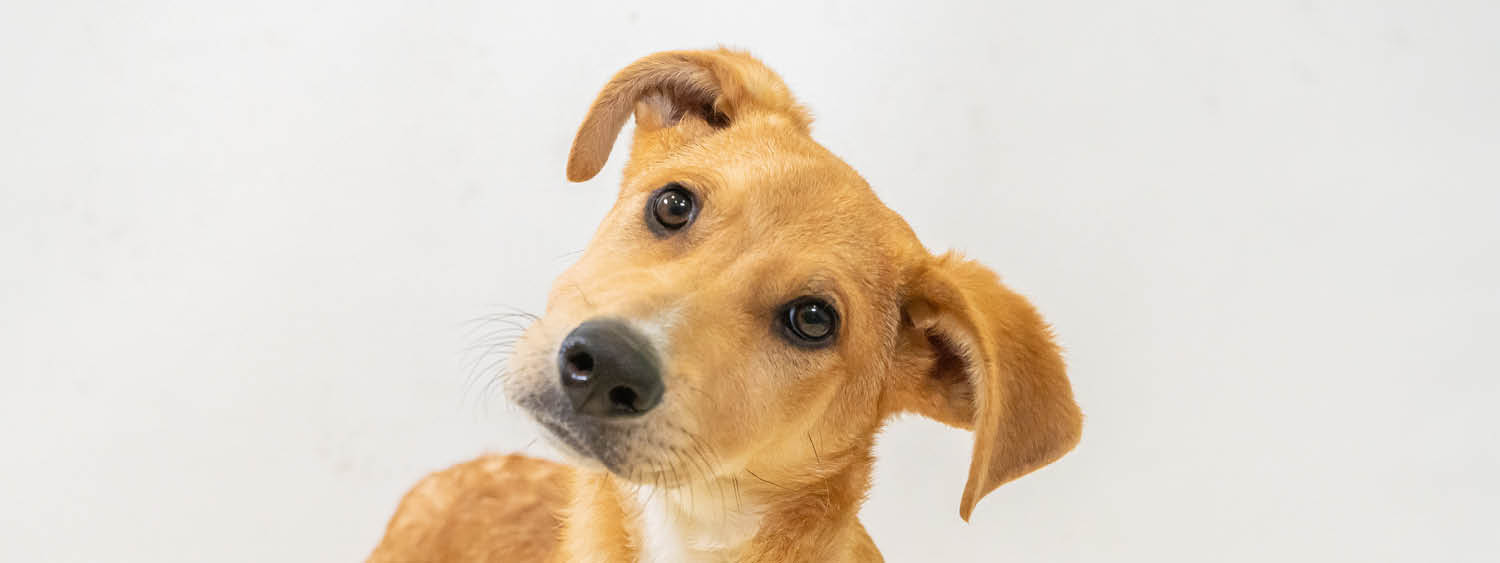

Text     → dog
Image    → dog
→ Final result: True

Final verdict: True
══════════════════════════════════════════════════════════════════════



In [6]:
# Example 1 – should be True
demo_check(
    "There is a beautiful cat in the picture.",
    "images/cat.jpg",
    "Cat – positive match"
)

# Example 2
demo_check(
    "This picture shows a dog here",
    "images/dog-hero.jpg",
    "Cow – positive"
)


══════════════════════════════════════════════════════════════════════
Demo: Brick – is not animal
Text: There is a beautiful brick in the picture.
Image: images/brick.jpg


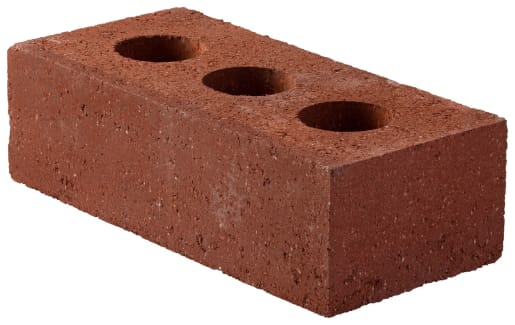

No animal found in text: There is a beautiful brick in the picture.

Final verdict: False
══════════════════════════════════════════════════════════════════════


══════════════════════════════════════════════════════════════════════
Demo: Cat – dog negative
Text: This picture shows a dog here
Image: images/cat.jpg


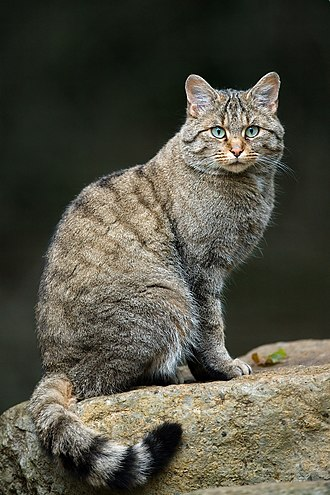

Text     → dog
Image    → cat
→ Final result: False

Final verdict: False
══════════════════════════════════════════════════════════════════════



In [9]:
# Example 1 – should be True
demo_check(
    "There is a beautiful brick in the picture.",
    "images/brick.jpg",
    "Brick – is not animal"
)

# Example 2
demo_check(
    "This picture shows a dog here",
    "images/cat.jpg",
    "Cat – dog negative"
)